# Objectif : Calculer la probabiliter de défaut

In [1]:
import numpy as np
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from src.discretization import (plot_bad_rate_by_quantile,prepare_chimerge,apply_chimerge,apply_binning,
                                check_binning_quality,compute_woe_iv,
                                chimerge_categorical)

In [2]:
df_credit = pd.read_csv("../data/output/df_credit_clear.csv",sep = ",")

### Discretisation

In [3]:
df_credit.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [4]:
df_credit_discretisation = df_credit.copy()

# ChiMerge — Méthode de discrétisation supervisée

## Définition

**ChiMerge (Chi-square Merge)** est une méthode de discrétisation supervisée
qui consiste à fusionner automatiquement des classes voisines
si elles n’ont pas de différence significative dans la variable cible (ex. le taux de défaut).

Autrement dit :
on regroupe les intervalles d’une variable tant qu’ils présentent le même risque de défaut,
selon un **test statistique du Chi²**.

---

## Objectif

### Objectif principal
Transformer une variable continue (âge, revenu, ratio prêt/revenu, etc.)
en **quelques classes homogènes en risque**, c’est-à-dire où les clients d’une même classe
ont le même comportement de défaut.

### Objectif pratique
- Supprimer le bruit (petites différences dues au hasard)
- Créer des bins statistiquement distincts
- Obtenir une relation monotone et stable avec la probabilité de défaut
- Préparer la variable pour le calcul du **WOE / IV** ou une **régression logistique**

---

## Fonctionnement

### Étape 1 — Découpage initial
Découper la variable en plusieurs petits intervalles (souvent 10 ou 20 déciles).

Exemple : `loan_percent_income`
→ (0–0.05], (0.05–0.10], (0.10–0.15], …

---

### Étape 2 — Calcul des effectifs par bin
Pour chaque intervalle, on compte :
- le nombre de **bons clients** (`loan_status = 0`)
- le nombre de **mauvais clients** (`loan_status = 1`)

---

### Étape 3 — Test du Chi² entre bins voisins
On teste l’hypothèse :
> “Ces deux bins ont le même taux de défaut.”

Le test du **χ² (Chi-square)** compare la répartition bons/mauvais entre deux classes adjacentes.

- Si la différence **n’est pas significative (p > 0.05)** → on les **fusionne**
- Si elle **est significative (p < 0.05)** → on les garde séparées

**On veut que chaque bin regroupe des individus “statistiquement similaires” et que les bins entre eux soient “statistiquement différents” en termes de risque.**

---

### Étape 4 — Répétition
On répète la fusion jusqu’à :
- atteindre un **seuil de significativité minimal**
- ou un **nombre cible de classes finales** (souvent 4 à 6)

---

### Étape 5 — Résultat
| Bin final | Intervalle | Taux de défaut | Interprétation |
|------------|-------------|----------------|----------------|
| 1 | (0–0.10] | 0.04 | Faible risque |
| 2 | (0.10–0.20] | 0.08 | Risque modéré |
| 3 | (0.20–0.40] | 0.20 | Risque élevé |
| 4 | (0.40–1.00] | 0.45 | Risque très élevé |

---

## Pourquoi c’est important

| Raison | Explication |
|--------|--------------|
| Stabilité | Moins sensible aux valeurs extrêmes ou au bruit |
| Interprétabilité | Chaque classe a un sens métier (“revenu faible”, “revenu moyen”, etc.) |
| Monotonicité | Le risque évolue dans un seul sens |
| Préparation au WOE | Les classes sont homogènes et distinctes en risque |

---

## Résumé

| Étape | Ce qu’on fait | Pourquoi |
|--------|----------------|-----------|
| 1️⃣ | Découper en petites classes (déciles) | Explorer le risque |
| 2️⃣ | Calculer bons/mauvais | Préparer le test |
| 3️⃣ | Appliquer le χ² sur classes voisines | Fusionner les bins similaires |
| 4️⃣ | Répéter jusqu’à seuil ou 5 classes | Obtenir des classes stables |
| 5️⃣ | Vérifier monotonicité / WOE | Finaliser la variable pour le modèle |

---

### En résumé

**ChiMerge** permet de simplifier une variable continue
en quelques classes stables et statistiquement distinctes
selon leur risque de défaut.  
C’est une étape clé dans la construction de modèles de scoring de crédit.


**Variable age :**

c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]


,person_age_bin,bad_rate
0,"(19.999, 22.0]",0.258841
1,"(22.0, 23.0]",0.218142
2,"(23.0, 24.0]",0.219824
3,"(24.0, 25.0]",0.228964
4,"(25.0, 26.0]",0.215582
5,"(26.0, 27.0]",0.212538
6,"(27.0, 29.0]",0.218279
7,"(29.0, 31.0]",0.206547
8,"(31.0, 36.0]",0.209948
9,"(36.0, 70.0]",0.213339


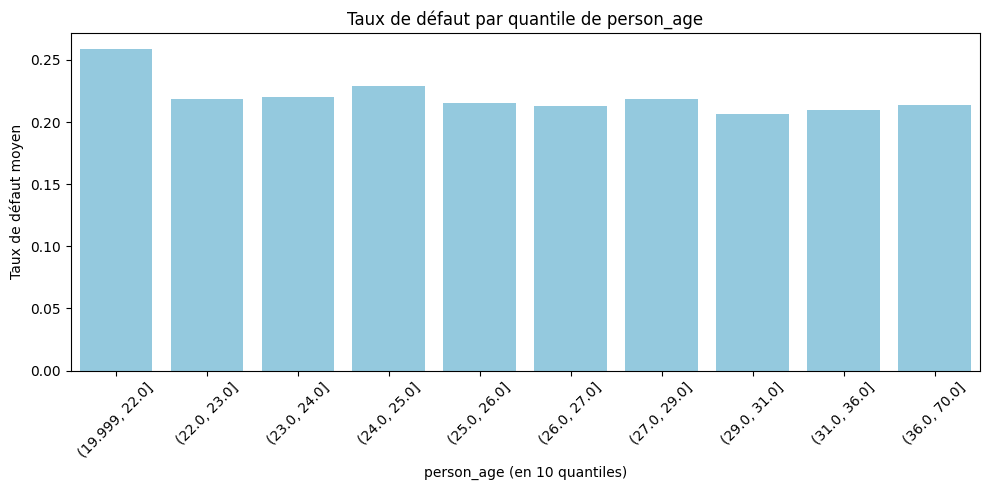

In [5]:
plot_bad_rate_by_quantile(df = df_credit_discretisation,
                          var = "person_age",
                          q = 10)

In [6]:
counts = prepare_chimerge(df_credit_discretisation, "person_age", q=10)
intervals = apply_chimerge(counts, max_bins=5)
intervals


c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]


,min,max,good,bad,total,bad_rate,pct_total
0,19.999,22.0,3416,1193,4609,0.258841,0.155023
1,22.000,25.0,7554,2153,9707,0.221799,0.326494
2,25.000,29.0,5806,1599,7405,0.215935,0.249067
3,29.000,70.0,6327,1683,8010,0.210112,0.269416


In [7]:
df_credit_discretisation_v1 = apply_binning(df_credit_discretisation,"person_age",intervals)


=== Vérification de la discrétisation : person_age ===
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      9707     0.221799
2  person_age_Bin3      7405     0.215935
3  person_age_Bin4      8010     0.210112

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


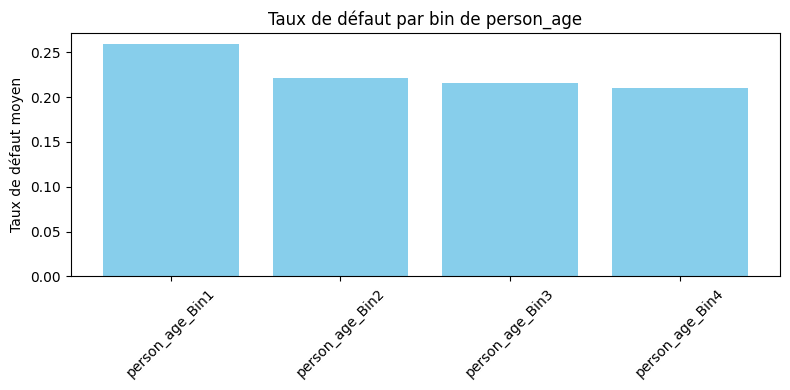

    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      9707     0.221799
2  person_age_Bin3      7405     0.215935
3  person_age_Bin4      8010     0.210112


In [8]:
print(check_binning_quality(df_credit_discretisation_v1,"person_age",target = "loan_status"))

In [9]:
woe_df, iv_value = compute_woe_iv(df_credit_discretisation_v1, "person_age_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour person_income : {iv_value:.4f}")


    person_age_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_age_Bin1   4609  1193  3416   0.147860  0.179994 -0.196660   
1  person_age_Bin2   9707  2153  7554   0.326971  0.324834  0.006556   
2  person_age_Bin3   7405  1599  5806   0.251309  0.241249  0.040854   
3  person_age_Bin4   8010  1683  6327   0.273861  0.253923  0.075589   

   IV_partial  
0    0.006320  
1    0.000014  
2    0.000411  
3    0.001507  

IV total pour person_income : 0.0083


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [10]:
df_credit_discretisation_v1.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'person_age_bin'],
      dtype='object')

**Variable : person_income**

c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]



=== Vérification de la discrétisation : person_income ===
    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


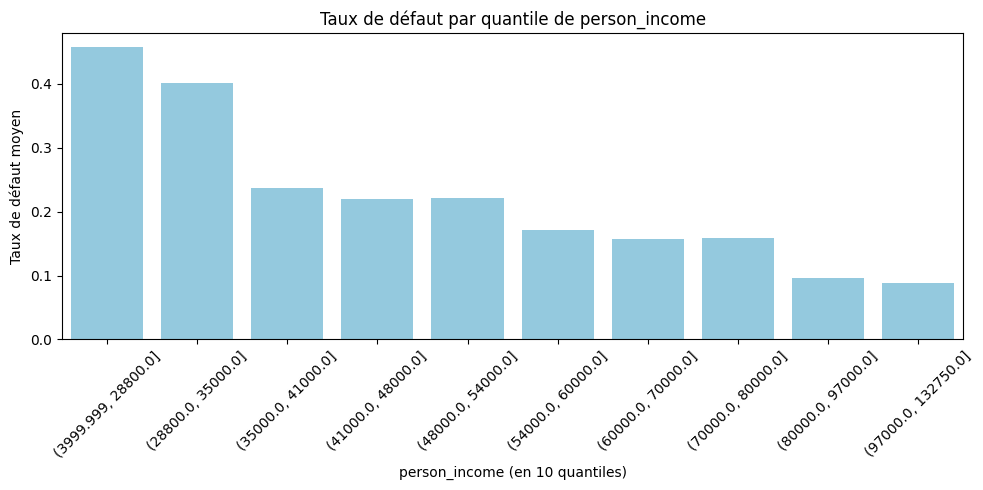

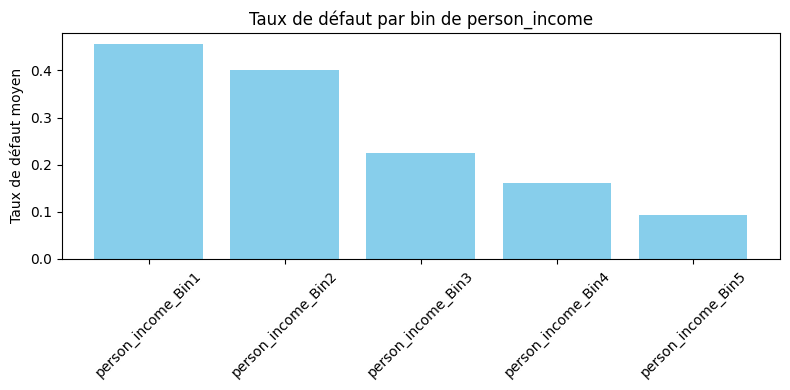

    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631
    person_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_income_Bin1   3081  1408  1673   0.072415  0.212432 -1.076211   
1  person_income_Bin2   3087  1241  1846   0.079903  0.187236 -0.851556   
2  person_income_Bin3   8823  1991  6832   0.295719  0.300392 -0.015679   
3  person_income_Bin4   8986  1455  7531   0.325975  0.219523  0.395363   
4  person_income_Bin5   5754   533  5221   0.225988  0.080416  1.033263   

   IV_partial  
0    0.150688  
1    0.091400  
2    0.000073  
3    0.042087  
4    0.150414  

IV total pour person_income : 0.4347


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [11]:
plot_bad_rate_by_quantile(df = df_credit_discretisation,
                          var = "person_income",
                          q = 10)


counts = prepare_chimerge(df_credit_discretisation, "person_income", q=10)
intervals = apply_chimerge(counts, max_bins=5)
intervals

df_credit_discretisation_v2 = apply_binning(df_credit_discretisation,"person_income",intervals)

print(check_binning_quality(df_credit_discretisation_v2,"person_income",target = "loan_status"))

woe_df, iv_value = compute_woe_iv(df_credit_discretisation_v1, "person_income_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour person_income : {iv_value:.4f}")


In [12]:
df_credit_discretisation_v2.head()

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin2,person_income_Bin1
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1


**Toutes les variables :**


=== Discrétisation de person_age ===

Intervalles finaux issus du ChiMerge :
      min   max  good   bad  total  bad_rate  pct_total
0  19.999  22.0  3416  1193   4609  0.258841   0.155023
1  22.000  25.0  7554  2153   9707  0.221799   0.326494
2  25.000  29.0  5806  1599   7405  0.215935   0.249067
3  29.000  70.0  6327  1683   8010  0.210112   0.269416

✅ Variable discrétisée ajoutée : person_age_bin

=== Vérification de la discrétisation : person_age ===
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      9707     0.221799
2  person_age_Bin3      7405     0.215935
3  person_age_Bin4      8010     0.210112

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


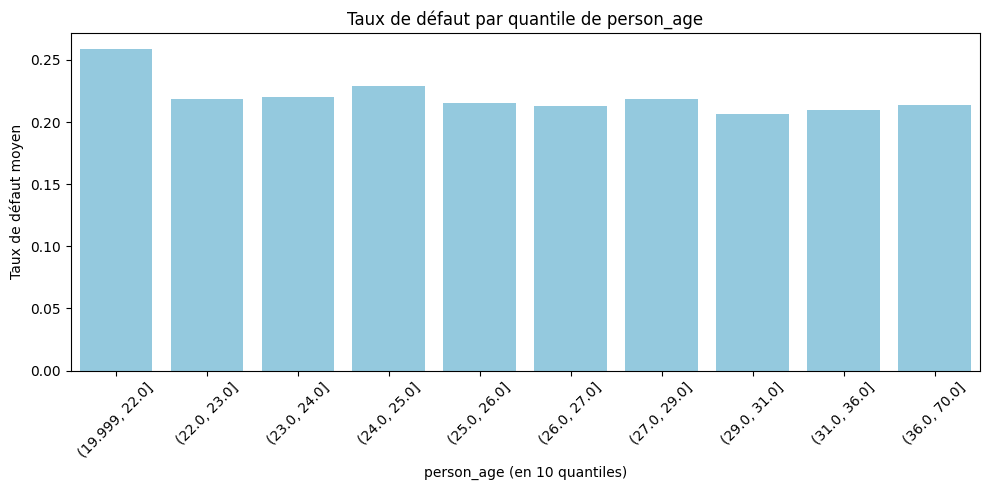

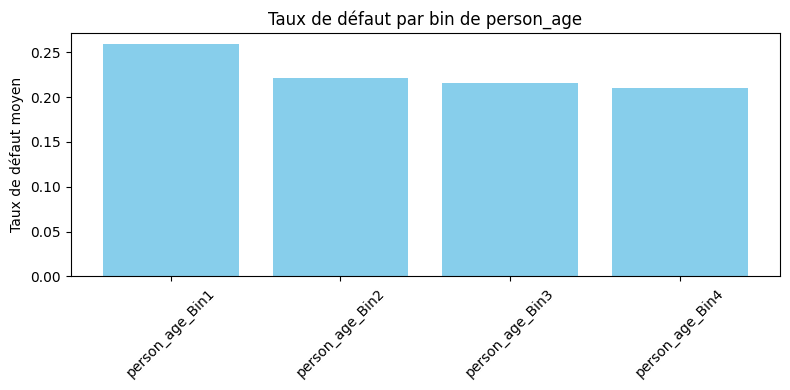


Vérification de la qualité du binning :
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      9707     0.221799
2  person_age_Bin3      7405     0.215935
3  person_age_Bin4      8010     0.210112

=== Résumé WOE/IV pour person_age ===
    person_age_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_age_Bin1   4609  1193  3416   0.147860  0.179994 -0.196660   
1  person_age_Bin2   9707  2153  7554   0.326971  0.324834  0.006556   
2  person_age_Bin3   7405  1599  5806   0.251309  0.241249  0.040854   
3  person_age_Bin4   8010  1683  6327   0.273861  0.253923  0.075589   

   IV_partial  
0    0.006320  
1    0.000014  
2    0.000411  
3    0.001507  

IV total pour person_age : 0.0083

=== Discrétisation de person_income ===

Intervalles finaux issus du ChiMerge :
         min       max  good   bad  total  bad_rate  pct_total
0   3999.999   28800.0  1673  1408   3081  0.456994   0.103629
1  28800.000   35000.0  184

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167:

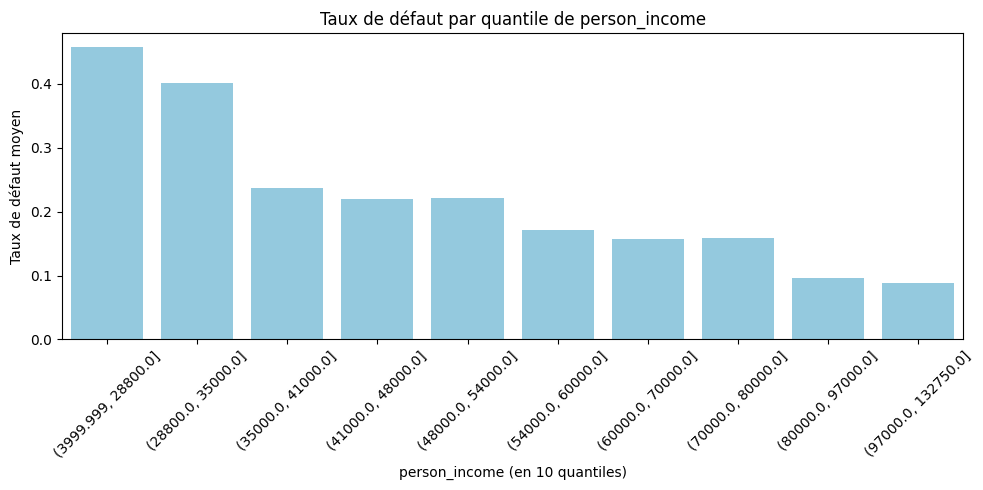

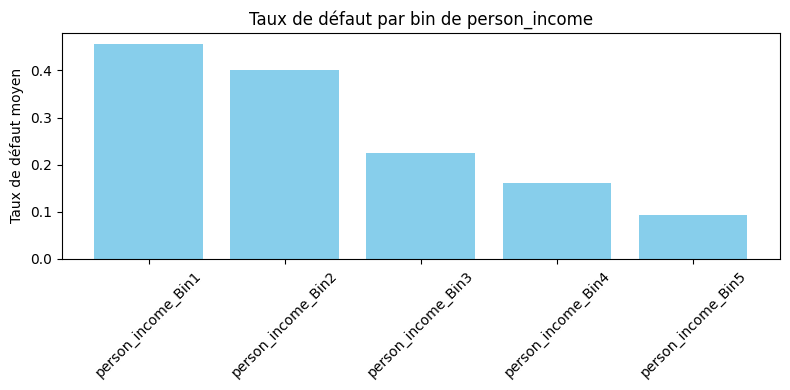


Vérification de la qualité du binning :
    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631

=== Résumé WOE/IV pour person_income ===
    person_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_income_Bin1   3081  1408  1673   0.072415  0.212432 -1.076211   
1  person_income_Bin2   3087  1241  1846   0.079903  0.187236 -0.851556   
2  person_income_Bin3   8823  1991  6832   0.295719  0.300392 -0.015679   
3  person_income_Bin4   8986  1455  7531   0.325975  0.219523  0.395363   
4  person_income_Bin5   5754   533  5221   0.225988  0.080416  1.033263   

   IV_partial  
0    0.150688  
1    0.091400  
2    0.000073  
3    0.042087  
4    0.150414  

IV total pour person_income : 0.4347

=== Discrétisation de person_emp_length ===

Intervalles fina

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167:

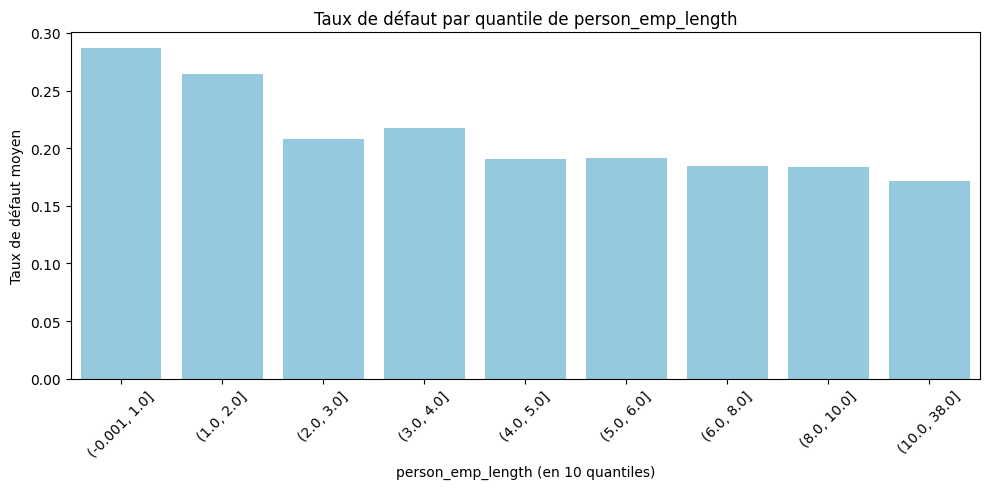

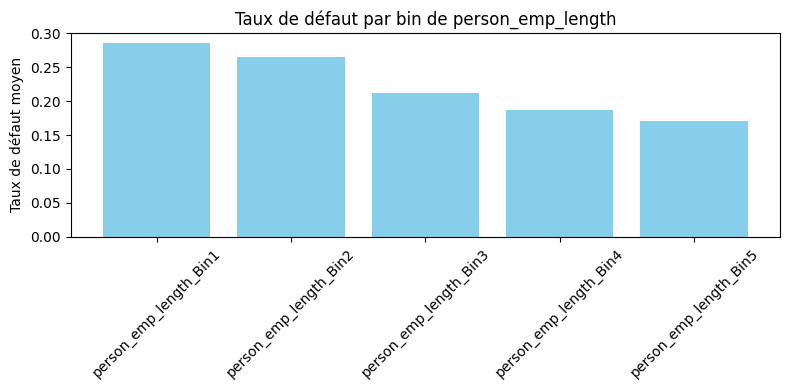


Vérification de la qualité du binning :
    person_emp_length_bin  effectif  taux_defaut
0  person_emp_length_Bin1      6679     0.286570
1  person_emp_length_Bin2      3647     0.264601
2  person_emp_length_Bin3      5992     0.212617
3  person_emp_length_Bin4     10864     0.187592
4  person_emp_length_Bin5      2549     0.171440

=== Résumé WOE/IV pour person_emp_length ===
    person_emp_length_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_emp_length_Bin1   6679  1914  4765   0.206250  0.288775 -0.336557   
1  person_emp_length_Bin2   3647   965  2682   0.116089  0.145594 -0.226469   
2  person_emp_length_Bin3   5992  1274  4718   0.204216  0.192215  0.060564   
3  person_emp_length_Bin4  10864  2038  8826   0.382028  0.307483  0.217074   
4  person_emp_length_Bin5   2549   437  2112   0.091417  0.065932  0.326798   

   IV_partial  
0    0.027774  
1    0.006682  
2    0.000727  
3    0.016182  
4    0.008328  

IV total pour person_emp_length : 0.0597

✅ Dis

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [13]:
# Liste des variables numériques à discrétiser
numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    # "loan_amnt",
    # "loan_percent_income",

]

# Copie de travail
df_credit_discret = df_credit.copy()

# Boucle principale
for var in numeric_vars:
    print("\n" + "=" * 80)
    print(f"=== Discrétisation de {var} ===")
    print("=" * 80)
    
    try:
        # 1️⃣ Plot du taux de défaut initial
        plot_bad_rate_by_quantile(df_credit_discret, var, q=10)
        
        # 2️⃣ Application du ChiMerge avec contrôle du nombre de bins
        counts = prepare_chimerge(df_credit_discret, var, q=10)

        n_init_bins = counts.shape[0]
        desired_bins = min(5, n_init_bins)

        intervals = apply_chimerge(counts, max_bins=desired_bins)

        if len(intervals) > 5:
            print(f"⚠️ {var}: {len(intervals)} bins détectés — réduction à 5 par fusion finale.")
            intervals = intervals.iloc[:5].copy()
            intervals.loc[4, "max"] = counts["max"].max()

        print("\nIntervalles finaux issus du ChiMerge :")
        print(intervals)

        # 3️⃣ Application du binning directement dans df_credit_discret
        df_credit_discret = apply_binning(df_credit_discret, var, intervals)
        print(f"\n✅ Variable discrétisée ajoutée : {var}_bin")
        
        # 4️⃣ Vérification de la qualité du binning
        quality_check = check_binning_quality(df_credit_discret, var, target="loan_status")
        print("\nVérification de la qualité du binning :")
        print(quality_check)
        
        # 5️⃣ Calcul du WOE & IV
        var_bin_name = f"{var}_bin"
        woe_df, iv_value = compute_woe_iv(df_credit_discret, var_bin_name, "loan_status")
        
        print(f"\n=== Résumé WOE/IV pour {var} ===")
        print(woe_df)
        print(f"\nIV total pour {var} : {iv_value:.4f}")

    except Exception as e:
        print(f"⚠️ Erreur lors du traitement de {var} : {e}")

print("\n✅ Discrétisation terminée pour toutes les variables numériques.")


In [14]:
df_credit_discret.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'person_age_bin', 'person_income_bin', 'person_emp_length_bin'],
      dtype='object')

In [15]:
df_credit_discret

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin,person_emp_length_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin4
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin2,person_income_Bin1,person_emp_length_Bin1
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4,person_emp_length_Bin3
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4,person_emp_length_Bin4
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29726,32575,52,64500,RENT,0.0,EDUCATION,B,5000,11.26,0,0.08,N,20,person_age_Bin4,person_income_Bin4,person_emp_length_Bin1
29727,32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,person_age_Bin4,person_income_Bin3,person_emp_length_Bin1
29728,32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,person_age_Bin4,person_income_Bin5,person_emp_length_Bin3
29729,32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,person_age_Bin4,person_income_Bin4,person_emp_length_Bin3


In [16]:
# 🔍 Afficher les effectifs des variables discrétisées (toutes celles finissant par "_bin")
bin_vars = [col for col in df_credit_discret.columns if col.endswith("_bin")]


for var in bin_vars:
    print(f"\n📊 {var} :")
    print(df_credit_discret[var].value_counts(dropna=False).sort_index())



📊 person_age_bin :
person_age_bin
person_age_Bin1    4609
person_age_Bin2    9707
person_age_Bin3    7405
person_age_Bin4    8010
Name: count, dtype: int64

📊 person_income_bin :
person_income_bin
person_income_Bin1    3081
person_income_Bin2    3087
person_income_Bin3    8823
person_income_Bin4    8986
person_income_Bin5    5754
Name: count, dtype: int64

📊 person_emp_length_bin :
person_emp_length_bin
person_emp_length_Bin1     6679
person_emp_length_Bin2     3647
person_emp_length_Bin3     5992
person_emp_length_Bin4    10864
person_emp_length_Bin5     2549
Name: count, dtype: int64



=== Vérification de la discrétisation : loan_amnt ===
    loan_amnt_bin  effectif  taux_defaut
0  loan_amnt_Bin1     15674     0.186742
1  loan_amnt_Bin2      5186     0.203239
2  loan_amnt_Bin3      3160     0.222152
3  loan_amnt_Bin4      2991     0.291541
4  loan_amnt_Bin5      2720     0.394485

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


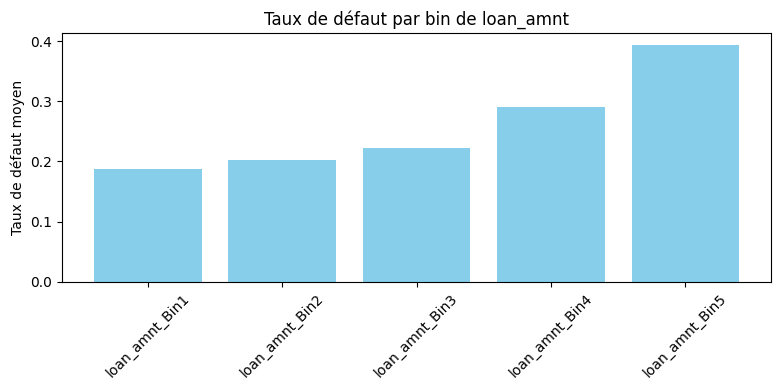

    loan_amnt_bin  effectif  taux_defaut
0  loan_amnt_Bin1     15674     0.186742
1  loan_amnt_Bin2      5186     0.203239
2  loan_amnt_Bin3      3160     0.222152
3  loan_amnt_Bin4      2991     0.291541
4  loan_amnt_Bin5      2720     0.394485

=== WOE et IV pour la variable 'loan_amnt' ===
    loan_amnt_bin  total   bad   good  dist_good  dist_bad       WOE  \
0  loan_amnt_Bin1  15674  2927  12747   0.551747  0.441611  0.222659   
1  loan_amnt_Bin2   5186  1054   4132   0.178851  0.159022  0.117510   
2  loan_amnt_Bin3   3160   702   2458   0.106393  0.105914  0.004511   
3  loan_amnt_Bin4   2991   872   2119   0.091720  0.131563 -0.360749   
4  loan_amnt_Bin5   2720  1073   1647   0.071289  0.161889 -0.820162   

   IV_partial  
0    0.024523  
1    0.002330  
2    0.000002  
3    0.014373  
4    0.074306  

IV total pour 'loan_amnt' : 0.1155


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [17]:
# --- Étape 1 : préparation du ChiMerge ---
counts = prepare_chimerge(df_credit_discret, var="loan_amnt", q=10, target="loan_status")

# --- Étape 2 : application du ChiMerge amélioré (monotone, stable, ≥ 5 % par bin) ---
intervals = apply_chimerge(
    counts,
    max_bins=5,
    significance=0.05,
    min_pct=0.05,             # chaque bin doit avoir ≥ 5 % des obs.
    enforce_monotonic=True    # force un profil monotone du taux de défaut
)

# --- Étape 3 : création des bins sur le jeu de données original ---
df_credit_discret_v2 = apply_binning(df_credit_discret, var="loan_amnt", intervals=intervals)

# --- Étape 4 : vérification visuelle et statistique de la qualité du binning ---
summary = check_binning_quality(df_credit_discret_v2, var="loan_amnt", target="loan_status", plot=True)
print(summary)

# --- Étape 5 : calcul du WOE et de l’IV ---
woe_df, iv_value = compute_woe_iv(df_credit_discret_v2, var_bin="loan_amnt_bin", target="loan_status")

print("\n=== WOE et IV pour la variable 'loan_amnt' ===")
print(woe_df)
print(f"\nIV total pour 'loan_amnt' : {iv_value:.4f}")


c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]



=== Taux de défaut par décile pour loan_percent_income ===
        loan_percent_income_bin  bad_rate
0  (0.009000000000000001, 0.06]  0.108412
1                  (0.06, 0.08]  0.135354
2                   (0.08, 0.1]  0.127106
3                   (0.1, 0.13]  0.122849
4                  (0.13, 0.15]  0.135412
5                  (0.15, 0.18]  0.169291
6                  (0.18, 0.21]  0.187455
7                  (0.21, 0.26]  0.206515
8                  (0.26, 0.32]  0.364555
9                  (0.32, 0.83]  0.711396

=== Intervalles finaux après ChiMerge ===
     min   max  good   bad  total  bad_rate  pct_total
0  0.009  0.06  3487   424   3911  0.108412   0.131546
1  0.060  0.15  9757  1448  11205  0.129228   0.376879
2  0.150  0.21  4786  1036   5822  0.177946   0.195823
3  0.210  0.26  2582   672   3254  0.206515   0.109448
4  0.260  0.32  1635   938   2573  0.364555   0.086543
5  0.320  0.83   856  2110   2966  0.711396   0.099761

=== Vérification de la discrétisation : loan_perc

c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


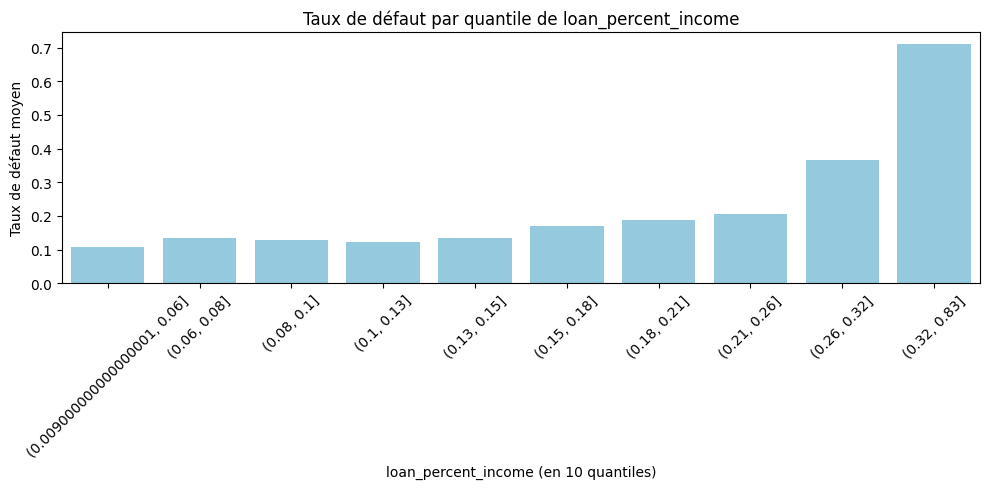

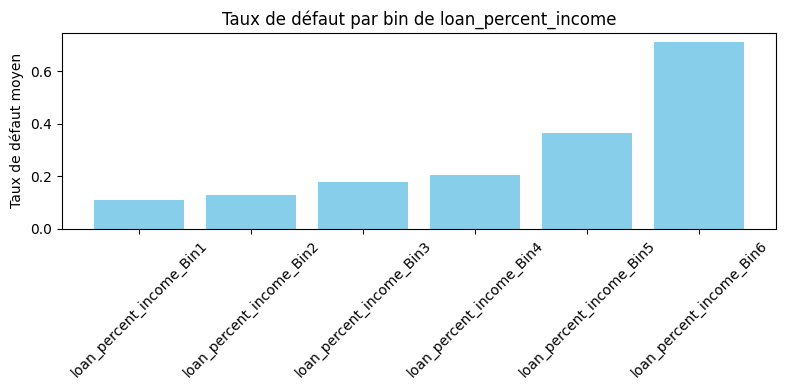


=== Vérification de la discrétisation ===
    loan_percent_income_bin  effectif  taux_defaut
0  loan_percent_income_Bin1      3911     0.108412
1  loan_percent_income_Bin2     11205     0.129228
2  loan_percent_income_Bin3      5822     0.177946
3  loan_percent_income_Bin4      3254     0.206515
4  loan_percent_income_Bin5      2573     0.364555
5  loan_percent_income_Bin6      2966     0.711396

=== WOE et IV pour 'loan_percent_income' ===
    loan_percent_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  loan_percent_income_Bin1   3911   424  3487   0.150933  0.063971  0.858404   
1  loan_percent_income_Bin2  11205  1448  9757   0.422326  0.218467  0.659142   
2  loan_percent_income_Bin3   5822  1036  4786   0.207159  0.156307  0.281668   
3  loan_percent_income_Bin4   3254   672  2582   0.111760  0.101388  0.097402   
4  loan_percent_income_Bin5   2573   938  1635   0.070770  0.141521 -0.693011   
5  loan_percent_income_Bin6   2966  2110   856   0.037051  0.318346 

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [18]:
# --- Étape 0 : visualisation du taux de défaut par déciles ---
bad_rate_deciles = plot_bad_rate_by_quantile(
    df=df_credit_discret_v2,
    var="loan_percent_income",
    q=10,
    target="loan_status"
)

print("\n=== Taux de défaut par décile pour loan_percent_income ===")
print(bad_rate_deciles)


# --- Étape 1 : préparation du ChiMerge ---
counts = prepare_chimerge(df_credit_discret_v2, var="loan_percent_income", q=10, target="loan_status")

# --- Étape 2 : application du ChiMerge amélioré ---
intervals = apply_chimerge(
    counts,
    max_bins=5,
    significance=0.05,
    min_pct=0.05,             # chaque bin ≥ 5% des observations
    enforce_monotonic=True    # profil monotone du taux de défaut
)

print("\n=== Intervalles finaux après ChiMerge ===")
print(intervals)


# --- Étape 3 : application du binning sur le DataFrame ---
df_credit_discret_v3 = apply_binning(df_credit_discret_v2, var="loan_percent_income", intervals=intervals)

# --- Étape 4 : contrôle qualité du binning ---
summary = check_binning_quality(df_credit_discret_v3, var="loan_percent_income", target="loan_status", plot=True)
print("\n=== Vérification de la discrétisation ===")
print(summary)

# --- Étape 5 : calcul du WOE et de l’IV ---
woe_df, iv_value = compute_woe_iv(df_credit_discret_v3, var_bin="loan_percent_income_bin", target="loan_status")

print("\n=== WOE et IV pour 'loan_percent_income' ===")
print(woe_df)
print(f"\nIV total pour loan_percent_income : {iv_value:.4f}")



=== Taux de défaut par décile pour cb_person_cred_hist_length ===
  cb_person_cred_hist_length_bin  bad_rate
0                   (1.999, 3.0]  0.232277
1                     (3.0, 4.0]  0.229189
2                     (4.0, 5.0]  0.209289
3                     (5.0, 7.0]  0.207592
4                     (7.0, 9.0]  0.215906
5                    (9.0, 11.0]  0.208191
6                   (11.0, 30.0]  0.219568

=== Intervalles finaux après ChiMerge ===
     min   max   good   bad  total  bad_rate  pct_total
0  1.999   4.0  12742  3833  16575  0.231252   0.557499
1  4.000  30.0  10361  2795  13156  0.212451   0.442501

=== Vérification de la discrétisation : cb_person_cred_hist_length ===
    cb_person_cred_hist_length_bin  effectif  taux_defaut
0  cb_person_cred_hist_length_Bin1     16575     0.231252
1  cb_person_cred_hist_length_Bin2     13156     0.212451

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:423: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


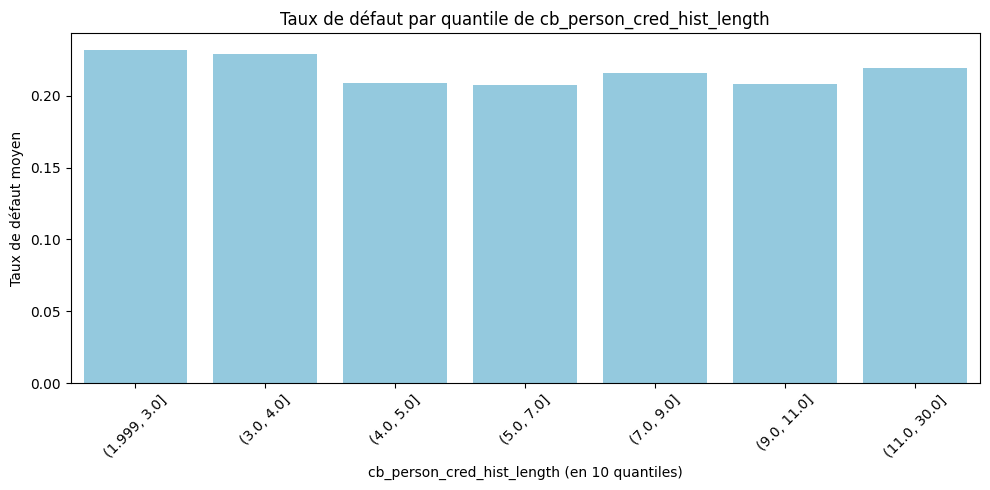

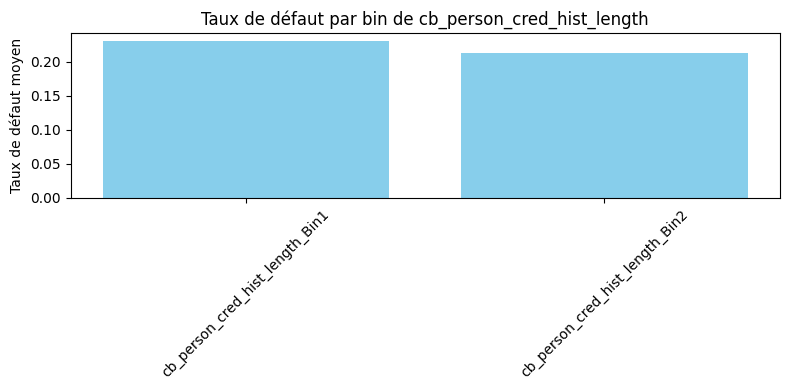


=== Vérification de la discrétisation ===
    cb_person_cred_hist_length_bin  effectif  taux_defaut
0  cb_person_cred_hist_length_Bin1     16575     0.231252
1  cb_person_cred_hist_length_Bin2     13156     0.212451

=== WOE et IV pour 'cb_person_cred_hist_length' ===
    cb_person_cred_hist_length  total   bad  good  dist_good  dist_bad  \
0                            2   5541  1320  4221   0.182704  0.199155   
1                            3   5532  1252  4280   0.185257  0.188896   
2                            4   5502  1261  4241   0.183569  0.190253   
3                            5   1701   356  1345   0.058218  0.053712   
4                            6   1664   354  1310   0.056703  0.053410   
5                            7   1708   346  1362   0.058953  0.052203   
6                            8   1708   372  1336   0.057828  0.056126   
7                            9   1687   361  1326   0.057395  0.054466   
8                           10   1647   346  1301   0.056313  0.

In [19]:
# --- Étape 0 : visualisation du taux de défaut par déciles ---
bad_rate_deciles = plot_bad_rate_by_quantile(
    df=df_credit_discret_v3,
    var="cb_person_cred_hist_length",
    q=10,
    target="loan_status"
)

print("\n=== Taux de défaut par décile pour cb_person_cred_hist_length ===")
print(bad_rate_deciles)


# --- Étape 1 : préparation du ChiMerge ---
counts = prepare_chimerge(df_credit_discret_v3, var="cb_person_cred_hist_length", q=10, target="loan_status")

# --- Étape 2 : application du ChiMerge amélioré ---
intervals = apply_chimerge(
    counts,
    max_bins=5,
    significance=0.05,
    min_pct=0.05,             # chaque bin ≥ 5% des observations
    enforce_monotonic=True    # profil monotone du taux de défaut
)

print("\n=== Intervalles finaux après ChiMerge ===")
print(intervals)


# --- Étape 3 : application du binning sur le DataFrame ---
df_credit_discret_v4 = apply_binning(df_credit_discret_v3, var="cb_person_cred_hist_length", intervals=intervals)

# --- Étape 4 : contrôle qualité du binning ---
summary = check_binning_quality(df_credit_discret_v4, var="cb_person_cred_hist_length", target="loan_status", plot=True)
print("\n=== Vérification de la discrétisation ===")
print(summary)

# --- Étape 5 : calcul du WOE et de l’IV ---
woe_df, iv_value = compute_woe_iv(df_credit_discret_v4  , var_bin="cb_person_cred_hist_length", target="loan_status")

print("\n=== WOE et IV pour 'cb_person_cred_hist_length' ===")
print(woe_df)
print(f"\nIV total pour cb_person_cred_hist_length : {iv_value:.4f}")


In [20]:
# 🔍 Afficher les effectifs des variables discrétisées (toutes celles finissant par "_bin")
bin_vars = [col for col in df_credit_discret_v3.columns if col.endswith("_bin")]


for var in bin_vars:
    print(f"\n📊 {var} :")
    print(df_credit_discret[var].value_counts(dropna=False).sort_index())



📊 person_age_bin :
person_age_bin
person_age_Bin1    4609
person_age_Bin2    9707
person_age_Bin3    7405
person_age_Bin4    8010
Name: count, dtype: int64

📊 person_income_bin :
person_income_bin
person_income_Bin1    3081
person_income_Bin2    3087
person_income_Bin3    8823
person_income_Bin4    8986
person_income_Bin5    5754
Name: count, dtype: int64

📊 person_emp_length_bin :
person_emp_length_bin
person_emp_length_Bin1     6679
person_emp_length_Bin2     3647
person_emp_length_Bin3     5992
person_emp_length_Bin4    10864
person_emp_length_Bin5     2549
Name: count, dtype: int64

📊 loan_amnt_bin :
loan_amnt_bin
loan_amnt_Bin1    15674
loan_amnt_Bin2     5186
loan_amnt_Bin3     3160
loan_amnt_Bin4     2991
loan_amnt_Bin5     2720
Name: count, dtype: int64

📊 loan_percent_income_bin :
loan_percent_income_bin
loan_percent_income_Bin1     3911
loan_percent_income_Bin2    11205
loan_percent_income_Bin3     5822
loan_percent_income_Bin4     3254
loan_percent_income_Bin5     2573
loan

**Pareil mais pour les 2 variables categorielles qui ont + que 5 categories :**

c:\Mosef\scoring\projet\src\discretization.py:636: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, order=df[var].value_counts().index, palette="viridis")


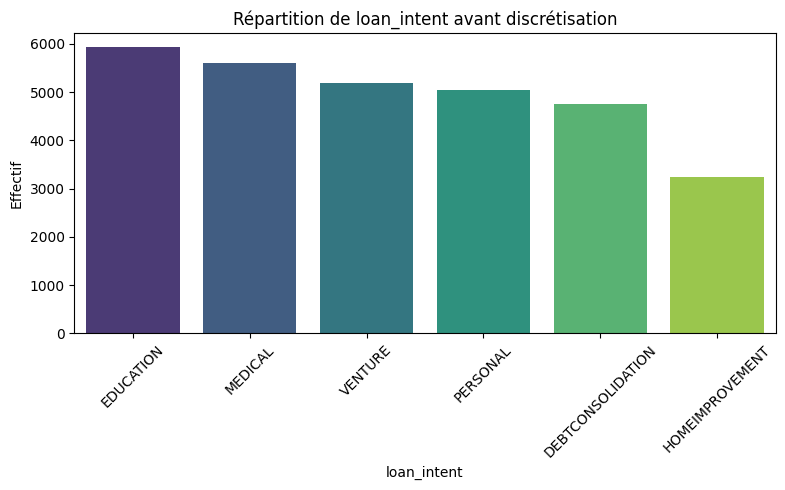

c:\Mosef\scoring\projet\src\discretization.py:645: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f"{var}_bin", order=sorted(df[f"{var}_bin"].unique()), palette="mako")


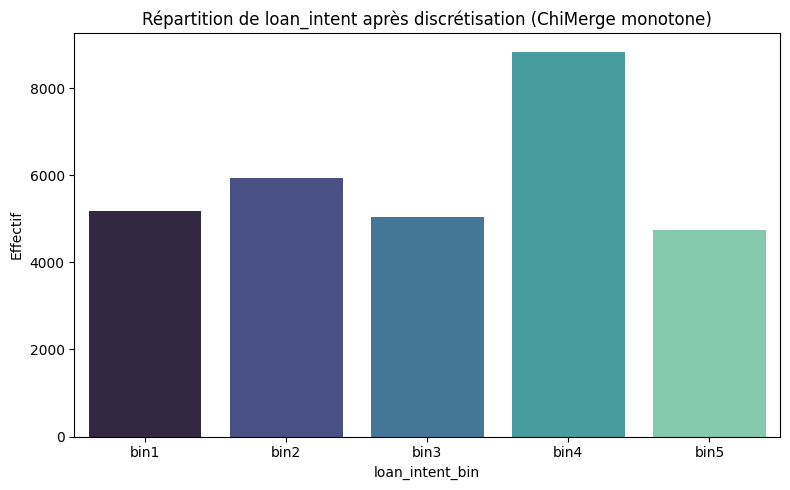

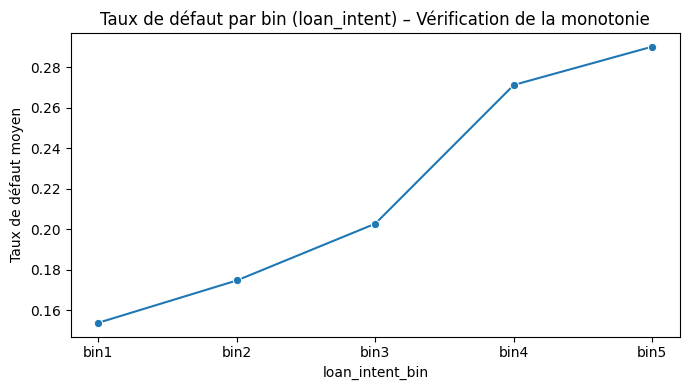


✅ Regroupement final monotone pour loan_intent :
  loan_intent_bin  taux_defaut  effectif  pct_total
0            bin1     0.153876      5186   0.174431
1            bin2     0.174756      5934   0.199590
2            bin3     0.202781      5035   0.169352
3            bin4     0.271234      8830   0.296996
4            bin5     0.290139      4746   0.159631

📊 Détails des regroupements :
 - VENTURE → bin1
 - EDUCATION → bin2
 - PERSONAL → bin3
 - HOMEIMPROVEMENT → bin4
 - MEDICAL → bin4
 - DEBTCONSOLIDATION → bin5


In [21]:
regroupement_loan_intent, df_credit_discret_v4 = chimerge_categorical(
    df=df_credit_discret_v3,
    var="loan_intent",
    target="loan_status",
    max_bins=5,      # max 5 groupes
    min_pct=0.05,    # au moins 5 % des observations par groupe
    verbose=True,
    enforce_monotonicity=True   # ✅ garantit que le taux de défaut est monotone
)



In [22]:
df_credit_discret_v4.head()

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin,person_emp_length_bin,loan_amnt_bin,loan_percent_income_bin,cb_person_cred_hist_length_bin,loan_intent_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin4,loan_amnt_Bin1,loan_percent_income_Bin2,cb_person_cred_hist_length_Bin1,bin2
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin2,person_income_Bin1,person_emp_length_Bin1,loan_amnt_Bin1,loan_percent_income_Bin6,cb_person_cred_hist_length_Bin1,bin4
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4,person_emp_length_Bin3,loan_amnt_Bin5,loan_percent_income_Bin6,cb_person_cred_hist_length_Bin1,bin4
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4,person_emp_length_Bin4,loan_amnt_Bin5,loan_percent_income_Bin6,cb_person_cred_hist_length_Bin1,bin4
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin2,loan_amnt_Bin1,loan_percent_income_Bin4,cb_person_cred_hist_length_Bin1,bin1


In [24]:
df_credit_discret_v4.to_csv(path_or_buf="../data/output/df_discretise.csv",
                            sep = ",")